
# Univariate Linear Regression — California Housing

## Objective

This notebook develops a univariate linear regression model to predict median house value using median income.

**Research Question:** Can median income predict the median house value in California census block groups?

- Predictor (X): `MedInc` — Median Income
- Target (y): `MedHouseVal` — Median House Value
- Dataset: California Housing Dataset

Two modelling approaches will be implemented:

1. Linear Regression from Scratch using Gradient Descent.
2. Linear Regression using scikit-learn.

Both implementations will be compared using RMSE, MAE, R², and regression visualizations.


In [1]:

# Import libraries for data handling and preprocessing

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("All required libraries imported successfully.")


All required libraries imported successfully.



## 1. Data Loading

The California Housing Dataset was previously collected and saved as a CSV file during the data-sourcing stage.

We load the saved CSV rather than download it again, helping keep the experiment reproducible.


In [2]:

# Load the California dataset from the raw data folder

df = pd.read_csv("../data/raw/california_housing.csv")

print("Dataset shape:", df.shape)

df.head()


Dataset shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



## 2. Feature Selection

For univariate linear regression, only one input variable is selected.

- X = `MedInc`
- y = `MedHouseVal`

The model will learn the relationship between median income and median house value.


In [3]:

# Select the predictor and target variable

X = df[["MedInc"]]
y = df["MedHouseVal"]

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.head())


Predictor shape: (20640, 1)
Target shape: (20640,)


,MedInc
0,8.3252
1,8.3014
2,7.2574
3,5.6431
4,3.8462


0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64


## 3. Data Cleaning

Before model training, we check whether the selected predictor or target contains missing values.

Observations with missing predictor or target values would be excluded from the modelling dataset. The original CSV remains unchanged.


In [4]:

# Create a modelling dataset using our selected variables

model_data = df[["MedInc", "MedHouseVal"]].copy()

# Check missing values before cleaning
print("Missing values before cleaning:")
print(model_data.isnull().sum())

# Remove missing predictor or target values, if any
model_data = model_data.dropna(
    subset=["MedInc", "MedHouseVal"]
)

# Separate X and y again after cleaning
X = model_data[["MedInc"]]
y = model_data["MedHouseVal"]

print("\nDataset shape after cleaning:", model_data.shape)

print("\nMissing values after cleaning:")
print(model_data.isnull().sum())


Missing values before cleaning:
MedInc         0
MedHouseVal    0
dtype: int64

Dataset shape after cleaning: (20640, 2)

Missing values after cleaning:
MedInc         0
MedHouseVal    0
dtype: int64



## 4. Train/Test Split

The dataset is divided into two subsets:

- Training data: 80%
- Testing data: 20%

The training subset is used to fit the regression model, while the testing subset is reserved for evaluating its performance on unseen observations.

A fixed random state of 42 ensures that the same data split can be reproduced.


In [5]:

# Split the dataset into training and testing subsets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (16512, 1)
X_test: (4128, 1)
y_train: (16512,)
y_test: (4128,)



## 5. Feature Standardization

Standardization transforms the predictor so that it has a mean close to zero and a standard deviation close to one.

The StandardScaler is fitted only on the training data and then applied to both training and testing data to prevent data leakage.

The target variable is kept in its original units for easier interpretation of model predictions and evaluation metrics.


In [6]:

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the training predictor
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing predictor using the same scaler
X_test_scaled = scaler.transform(X_test)

# Verify the standardized training data
print("Training mean:", round(X_train_scaled.mean(), 4))
print("Training standard deviation:", round(X_train_scaled.std(), 4))

print("\nFirst five standardized training values:")
print(X_train_scaled[:5])


Training mean: -0.0
Training standard deviation: 1.0

First five standardized training values:
[[-0.326196  ]
 [-0.03584338]
 [ 0.14470145]
 [-1.01786438]
 [-0.17148831]]



## 6. Linear Regression From Scratch

### Hypothesis Function

Univariate linear regression predicts a target value using one input feature.

The mathematical equation is:

$$
h_\theta(x) = \theta_0 + \theta_1 x
$$

Where:

- $h_\theta(x)$ is the predicted median house value.
- $x$ is the standardized median income.
- $\theta_0$ is the intercept.
- $\theta_1$ is the slope.

Our objective is to find the optimal values of $\theta_0$ and $\theta_1$ using gradient descent.


In [7]:

# Hypothesis function for univariate linear regression

def predict_from_scratch(x, theta_0, theta_1):
    return theta_0 + theta_1 * x



### Mean Squared Error (MSE) Cost Function

Mean Squared Error measures the average squared difference between actual and predicted values.

$$
MSE = \frac{1}{m}\sum_{i=1}^{m}(y_i-\hat{y}_i)^2
$$

Where:

- $m$ is the number of training observations.
- $y_i$ is the actual house value.
- $\hat{y}_i$ is the predicted house value.

The goal of gradient descent is to minimize this cost.


In [8]:

# Implement MSE from scratch using NumPy

def mse_cost(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)



### Gradient Descent Implementation

Gradient descent is an iterative optimization algorithm used to minimize the MSE cost function.

We begin with both model parameters set to zero. During each iteration, we calculate predictions, measure the error, compute the gradients, and update the parameters.

Initial experiment settings:

- Learning rate: 0.1
- Number of iterations: 1,000
- Initial intercept: 0
- Initial slope: 0

The cost history is recorded to visualize how the model learns.

These experimental settings will later be moved into `configs/experiment_config.yaml` as part of the MLOps architecture requirements.


In [9]:

# Implement Gradient Descent from scratch

def gradient_descent(x, y, learning_rate=0.1, iterations=1000):

    # Initialize parameters
    theta_0 = 0.0
    theta_1 = 0.0

    # Number of training observations
    m = len(y)

    # Store MSE after each iteration
    cost_history = []

    for i in range(iterations):

        # Step 1: Calculate predictions
        y_pred = predict_from_scratch(x, theta_0, theta_1)

        # Step 2: Calculate prediction errors
        errors = y_pred - y

        # Step 3: Calculate gradients
        gradient_0 = (2 / m) * np.sum(errors)
        gradient_1 = (2 / m) * np.sum(errors * x)

        # Step 4: Update parameters
        theta_0 -= learning_rate * gradient_0
        theta_1 -= learning_rate * gradient_1

        # Step 5: Calculate updated cost
        updated_predictions = predict_from_scratch(
            x, theta_0, theta_1
        )

        cost = mse_cost(y, updated_predictions)

        # Save cost
        cost_history.append(cost)

    return theta_0, theta_1, cost_history


### We have now implemented the entire gradient descent algorithm ourselves.


### Training the Model

The gradient descent model is trained using the standardized median income feature and the corresponding training target values.

The testing dataset is not used during training.


In [10]:

# Convert training data into one-dimensional NumPy arrays

x_train_np = X_train_scaled.ravel()

y_train_np = y_train.to_numpy(dtype=float)

# Train the model using Gradient Descent
theta_0, theta_1, cost_history = gradient_descent(
    x=x_train_np,
    y=y_train_np,
    learning_rate=0.1,
    iterations=1000
)

# Display the learned model parameters
print("Training completed successfully!")

print(f"Intercept (theta_0): {theta_0:.6f}")
print(f"Slope (theta_1): {theta_1:.6f}")

print(f"\nInitial MSE: {cost_history[0]:.6f}")
print(f"Final MSE: {cost_history[-1]:.6f}")


Training completed successfully!
Intercept (theta_0): 2.071947
Slope (theta_1): 0.798520

Initial MSE: 3.854727
Final MSE: 0.699145



### Gradient Descent Convergence

The following graph illustrates how Mean Squared Error changes throughout the gradient descent iterations.

A decreasing cost curve indicates that the optimization algorithm is reducing the training error.


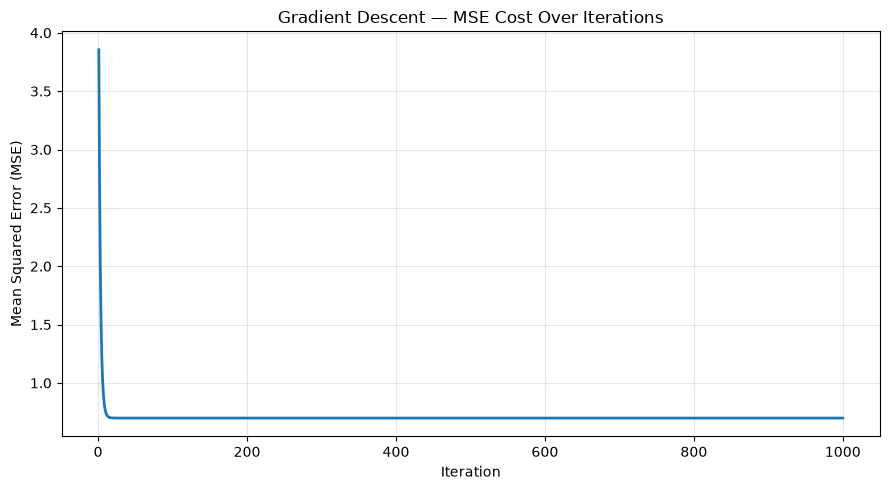

In [11]:

# Plot the MSE cost across iterations

plt.figure(figsize=(9, 5))

plt.plot(
    range(1, len(cost_history) + 1),
    cost_history,
    linewidth=2
)

plt.title("Gradient Descent — MSE Cost Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error (MSE)")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [12]:

# Verify that Gradient Descent completed successfully

print("Total iterations:", len(cost_history))

print(
    "Cost decreased:",
    cost_history[-1] < cost_history[0]
)

print(
    "Final cost is finite:",
    np.isfinite(cost_history[-1])
)


Total iterations: 1000
Cost decreased: True
Final cost is finite: True



## 7. Linear Regression Using Scikit-learn

Scikit-learn provides a built-in LinearRegression implementation.

We train the model using the same standardized training data used in our from-scratch implementation.

This allows us to compare both approaches under identical training conditions.

The scikit-learn implementation uses ordinary least squares to estimate the model parameters.


In [13]:

# Import LinearRegression from scikit-learn

from sklearn.linear_model import LinearRegression

# Initialize the regression model
sk_model = LinearRegression()

# Train using the same standardized training data
sk_model.fit(X_train_scaled, y_train)

# Display the learned model parameters
print("Scikit-learn model trained successfully!")

print(f"Intercept: {sk_model.intercept_:.6f}")
print(f"Slope: {sk_model.coef_[0]:.6f}")


Scikit-learn model trained successfully!
Intercept: 2.071947
Slope: 0.798520



## 8. Initial Model Comparison

Both models were trained using the same standardized median income predictor and training target values.

We compare their learned intercept, slope, and training MSE to check whether our gradient descent implementation produces results consistent with scikit-learn.

Final model evaluation on the testing dataset will be performed in the next section.


In [14]:

# Generate training predictions from both models

scratch_train_pred = predict_from_scratch(
    X_train_scaled.ravel(),
    theta_0,
    theta_1
)

sk_train_pred = sk_model.predict(X_train_scaled)

# Calculate training MSE for both implementations
scratch_train_mse = mse_cost(
    y_train.to_numpy(),
    scratch_train_pred
)

sk_train_mse = mse_cost(
    y_train.to_numpy(),
    sk_train_pred
)

# Create a comparison table
comparison_df = pd.DataFrame({
    "Parameter": [
        "Intercept",
        "Slope",
        "Training MSE"
    ],
    "From Scratch": [
        theta_0,
        theta_1,
        scratch_train_mse
    ],
    "Scikit-learn": [
        sk_model.intercept_,
        sk_model.coef_[0],
        sk_train_mse
    ]
})

comparison_df.round(6)


,Parameter,From Scratch,Scikit-learn
0,Intercept,2.071947,2.071947
1,Slope,0.798520,0.798520
2,Training MSE,0.699145,0.699145


In [15]:

# Compare the learned parameters

intercept_difference = abs(
    theta_0 - sk_model.intercept_
)

slope_difference = abs(
    theta_1 - sk_model.coef_[0]
)

mse_difference = abs(
    scratch_train_mse - sk_train_mse
)

print(f"Intercept difference: {intercept_difference:.8f}")
print(f"Slope difference: {slope_difference:.8f}")
print(f"Training MSE difference: {mse_difference:.8f}")

# Verify that the models produce approximately equal results
print(
    "\nModels have approximately equal parameters:",
    np.isclose(theta_0, sk_model.intercept_, atol=1e-4)
    and np.isclose(theta_1, sk_model.coef_[0], atol=1e-4)
)


Intercept difference: 0.00000000
Slope difference: 0.00000000
Training MSE difference: 0.00000000

Models have approximately equal parameters: True



## 9. Model Evaluation

### Generate Predictions on Testing Data

Both regression models are evaluated using the same testing dataset.

The from-scratch implementation uses its learned intercept and slope, while the scikit-learn implementation uses its built-in `predict()` method.

Using identical testing observations allows us to compare their predictive performance consistently.


In [16]:

# Prepare testing data for the from-scratch model

x_test_np = X_test_scaled.ravel()
y_test_np = y_test.to_numpy(dtype=float)

# Generate predictions using our from-scratch model
scratch_test_pred = predict_from_scratch(
    x_test_np,
    theta_0,
    theta_1
)

# Generate predictions using scikit-learn
sk_test_pred = sk_model.predict(X_test_scaled)

print("Actual test values:", len(y_test_np))
print("From-scratch predictions:", len(scratch_test_pred))
print("Scikit-learn predictions:", len(sk_test_pred))


Actual test values: 4128
From-scratch predictions: 4128
Scikit-learn predictions: 4128



### Evaluation Metrics

We evaluate the models using three metrics:

**1. Root Mean Squared Error (RMSE)**

$$
RMSE = \sqrt{\frac{1}{m}\sum_{i=1}^{m}(y_i-\hat{y}_i)^2}
$$

**2. Mean Absolute Error (MAE)**

$$
MAE = \frac{1}{m}\sum_{i=1}^{m}|y_i-\hat{y}_i|
$$

**3. Coefficient of Determination (R²)**

$$
R^2 = 1-\frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}
$$

Lower RMSE and MAE values indicate smaller prediction errors. Higher R² values indicate greater explanatory power relative to predicting the test-set mean.

RMSE and MAE are reported in the original target units (units of $100,000 USD).


In [17]:

# Import evaluation metrics

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Create a reusable evaluation function
def evaluate_model(y_true, y_pred):

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }


In [18]:

# Evaluate our from-scratch implementation

scratch_metrics = evaluate_model(
    y_test_np,
    scratch_test_pred
)

# Evaluate the scikit-learn implementation

sk_metrics = evaluate_model(
    y_test_np,
    sk_test_pred
)

# Display results in a comparison table

evaluation_df = pd.DataFrame({
    "Model": [
        "From Scratch",
        "Scikit-learn"
    ],
    "RMSE": [
        scratch_metrics["RMSE"],
        sk_metrics["RMSE"]
    ],
    "MAE": [
        scratch_metrics["MAE"],
        sk_metrics["MAE"]
    ],
    "R2": [
        scratch_metrics["R2"],
        sk_metrics["R2"]
    ]
})

evaluation_df.round(6)


,Model,RMSE,MAE,R2
0,From Scratch,0.84209,0.629909,0.458859
1,Scikit-learn,0.84209,0.629909,0.458859



### Actual vs. Predicted Values

The following table compares actual median house values with predictions generated by both regression models.

Only the first 10 testing observations are displayed for readability.


In [19]:

# Compare actual and predicted test values

predictions_df = pd.DataFrame({
    "Actual Value": y_test_np,
    "From Scratch": scratch_test_pred,
    "Scikit-learn": sk_test_pred
})

predictions_df.head(10).round(4)


,Actual Value,From Scratch,Scikit-learn
0,0.477,1.1496,1.1496
1,0.458,1.5061,1.5061
2,5.000,1.9039,1.9039
3,2.186,2.8506,2.8506
4,2.780,2.0066,2.0066
5,1.587,2.4217,2.4217
6,1.982,2.5765,2.5765
7,1.575,1.9923,1.9923
8,3.400,2.4589,2.4589
9,4.466,3.8468,3.8468


In [20]:

# Verify that both models were evaluated correctly

print("Testing observations:", len(y_test_np))

print(
    "From-scratch predictions are finite:",
    np.isfinite(scratch_test_pred).all()
)

print(
    "Scikit-learn predictions are finite:",
    np.isfinite(sk_test_pred).all()
)

print(
    "Both models produce approximately equal predictions:",
    np.allclose(
        scratch_test_pred,
        sk_test_pred,
        atol=1e-4
    )
)


Testing observations: 4128
From-scratch predictions are finite: True
Scikit-learn predictions are finite: True
Both models produce approximately equal predictions: True



## 10. Regression Line Visualization

The following visualization compares the actual California housing observations with the regression lines generated by both implementations.

The horizontal axis displays the original median income values, while the predictions were generated using the standardized test data.

Both regression lines are expected to overlap because the implementations produced almost identical model parameters.


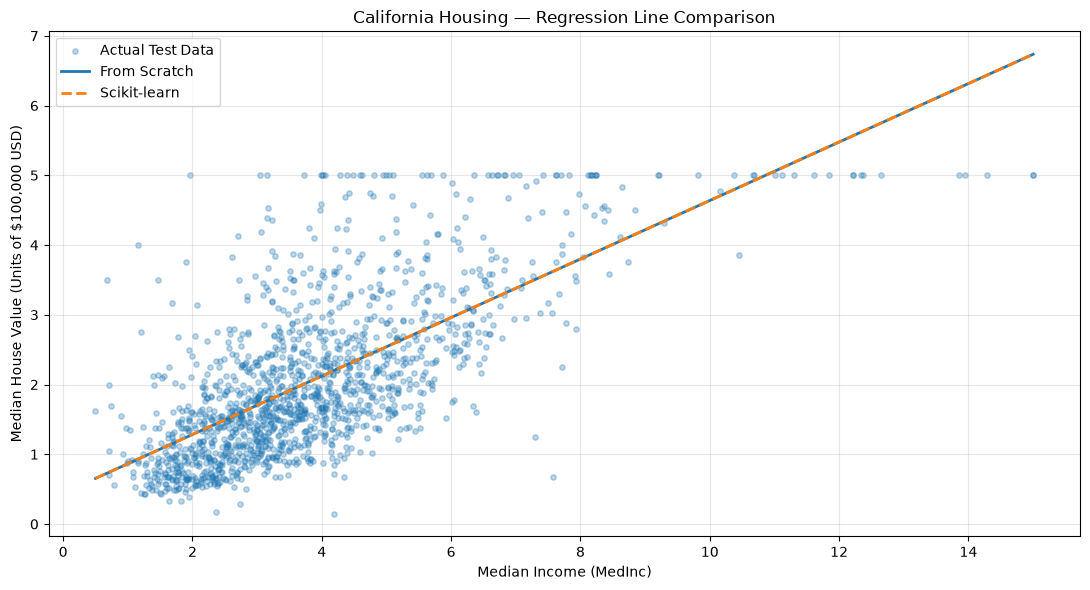

In [21]:

# Get the original median income values for plotting
x_test_original = X_test["MedInc"].to_numpy()

# Sort the income values so regression lines are drawn correctly
sorted_indices = np.argsort(x_test_original)

# Create a reproducible sample of testing observations
rng = np.random.default_rng(42)

sample_indices = rng.choice(
    len(x_test_original),
    size=min(1500, len(x_test_original)),
    replace=False
)

plt.figure(figsize=(11, 6))

# Actual testing observations
plt.scatter(
    x_test_original[sample_indices],
    y_test_np[sample_indices],
    alpha=0.3,
    s=15,
    label="Actual Test Data"
)

# From-scratch regression line
plt.plot(
    x_test_original[sorted_indices],
    scratch_test_pred[sorted_indices],
    linewidth=2,
    label="From Scratch"
)

# Scikit-learn regression line
plt.plot(
    x_test_original[sorted_indices],
    sk_test_pred[sorted_indices],
    linestyle="--",
    linewidth=2,
    label="Scikit-learn"
)

plt.title("California Housing — Regression Line Comparison")
plt.xlabel("Median Income (MedInc)")
plt.ylabel("Median House Value (Units of $100,000 USD)")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



### Actual vs. Predicted House Values

This scatter plot compares the actual testing values with the predictions produced by the scikit-learn model.

The dashed diagonal line represents perfect predictions, where actual and predicted values are equal.

Points farther from this line represent larger prediction errors.


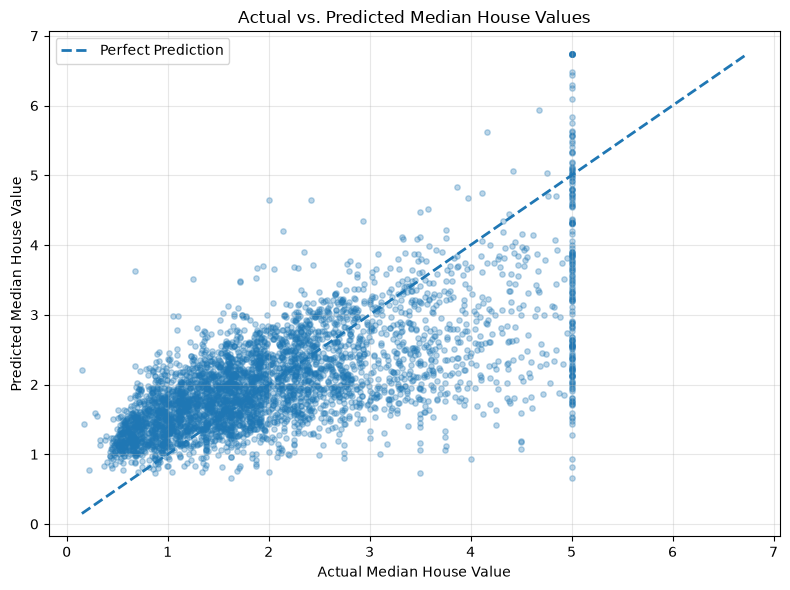

In [22]:

plt.figure(figsize=(8, 6))

# Plot actual vs predicted values
plt.scatter(
    y_test_np,
    sk_test_pred,
    alpha=0.3,
    s=15
)

# Reference line for perfect predictions
min_value = min(y_test_np.min(), sk_test_pred.min())
max_value = max(y_test_np.max(), sk_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title("Actual vs. Predicted Median House Values")
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



## 11. Key Findings and Conclusion

### Model Comparison

Two univariate linear regression models were implemented to predict median house value using median income in the California Housing Dataset.

The first model was implemented from scratch using NumPy and gradient descent. The second used scikit-learn's LinearRegression implementation.

Both models were trained using the same standardized training data and evaluated using the same testing dataset.

### Evaluation Results

| Model | RMSE | MAE | R² |
|---|---:|---:|---:|
| From Scratch | 0.842090 | 0.629909 | 0.458859 |
| Scikit-learn | 0.842090 | 0.629909 | 0.458859 |

### Key Findings

- Gradient descent successfully minimized the MSE cost function.
- Both implementations produced almost identical intercepts, slopes, and predictions.
- Median income showed a positive relationship with median house value.
- The R² score of approximately 0.459 indicates that the model explains around 45.9% of the variation in median house values in the testing dataset.
- Median income alone does not capture all factors affecting housing values.
- The historical dataset also contains capped target values, which limit the representation of higher-valued areas.

### Conclusion

This experiment demonstrates how univariate linear regression can be implemented from scratch and compared with an established machine learning library.

Both models achieved equivalent evaluation results, validating the implementation of gradient descent.

The next stage of the workshop will refactor the notebook into independent Python modules for data loading, preprocessing, modelling, and evaluation, following MLOps architecture principles.
